# Instructor Effectiveness Modeling (EdTech Context)

### Importing libraries

In [40]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import MinMaxScaler

In [ ]:
## Load the Dataset

df = pd.read_csv("instructor_effectiveness_dataset.csv")

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (2000, 12)


,batch_id,instructor_id,course_id,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate
0,B_1861,I_044,C_01,0.300000,14.225955,73.546528,0.647423,0.774572,0.790918,0.108414,3.766211,0.533193
1,B_0354,I_119,C_06,0.657220,22.871110,77.312331,0.425098,0.494936,0.998566,0.280550,5.000000,0.734087
2,B_1334,I_050,C_03,0.300000,16.087517,79.563687,0.700000,0.977901,0.807298,0.207013,3.517386,0.681433
3,B_0906,I_024,C_21,0.639507,24.260687,99.295316,0.334657,0.846515,0.544555,0.306395,4.207578,1.000000
4,B_1290,I_001,C_08,0.527302,31.081556,99.393425,0.521099,0.917450,0.865885,0.252289,4.426230,0.696710


In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   batch_id                    2000 non-null   object 
 1   instructor_id               2000 non-null   object 
 2   course_id                   2000 non-null   object 
 3   completion_rate             2000 non-null   float64
 4   avg_score_improvement       2000 non-null   float64
 5   avg_quiz_score              2000 non-null   float64
 6   dropout_rate                2000 non-null   float64
 7   avg_watch_time              2000 non-null   float64
 8   assignment_submission_rate  2000 non-null   float64
 9   forum_activity_rate         2000 non-null   float64
 10  avg_feedback_score          2000 non-null   float64
 11  feedback_response_rate      2000 non-null   float64
dtypes: float64(9), object(3)
memory usage: 187.6+ KB


In [43]:
## statistical summary

df.describe()

,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,0.602808,27.035844,77.956126,0.394883,0.776515,0.753188,0.250300,4.207134,0.736519
std,0.159667,5.716641,10.695618,0.162747,0.145231,0.148058,0.100640,0.419209,0.149412
min,0.300000,6.159240,40.386725,0.020000,0.287440,0.251111,0.000000,2.639915,0.259935
25%,0.489260,23.124673,70.897590,0.280035,0.675076,0.652110,0.179845,3.918986,0.633293
50%,0.603091,26.938629,78.020567,0.394820,0.780330,0.756380,0.249771,4.205989,0.737213
75%,0.712797,30.885600,85.444286,0.511432,0.894242,0.856458,0.319204,4.503437,0.845876
max,0.980000,40.000000,100.000000,0.700000,1.000000,1.000000,0.641111,5.000000,1.000000


In [44]:
## Check Missing Values

df.isnull().sum()

batch_id                      0
instructor_id                 0
course_id                     0
completion_rate               0
avg_score_improvement         0
avg_quiz_score                0
dropout_rate                  0
avg_watch_time                0
assignment_submission_rate    0
forum_activity_rate           0
avg_feedback_score            0
feedback_response_rate        0
dtype: int64

## Exploratory Data Analysis (EDA)


In this step we explore the dataset to understand feature distributions,
identify correlations, and detect missing values or anomalies.

### Feature Distribution

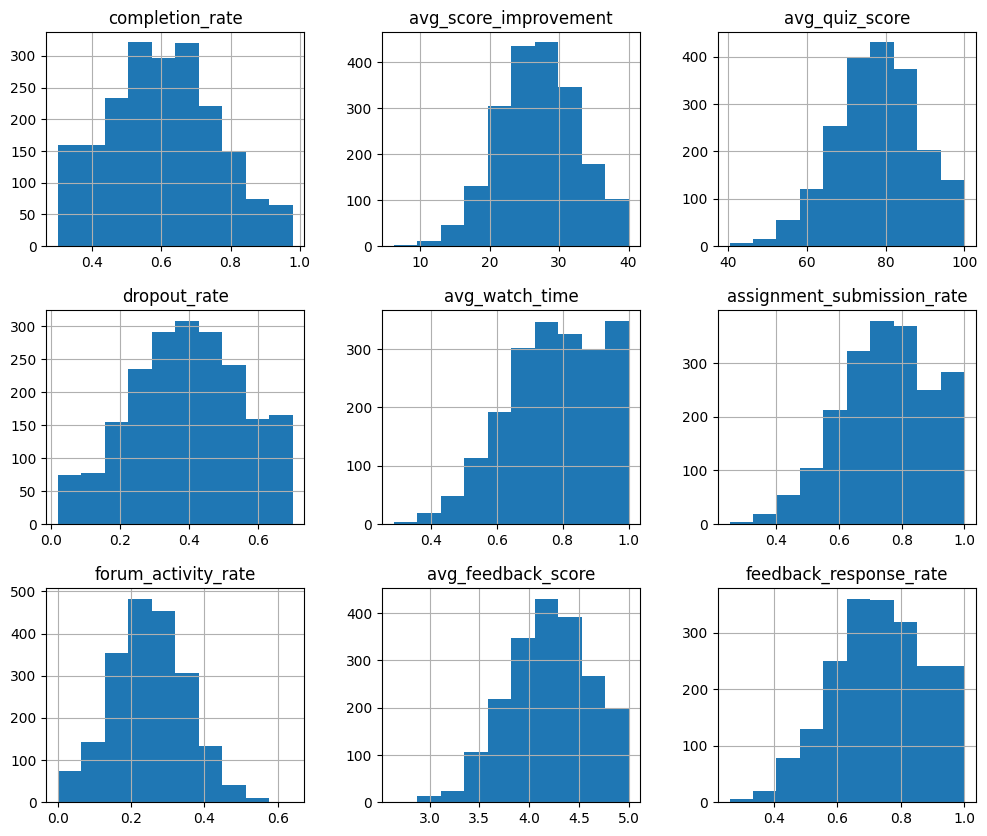

In [45]:
## Histograms help visualize how different variables are distributed across batches

df.hist(figsize=(12,10))
plt.show()

### Correlation Analysis

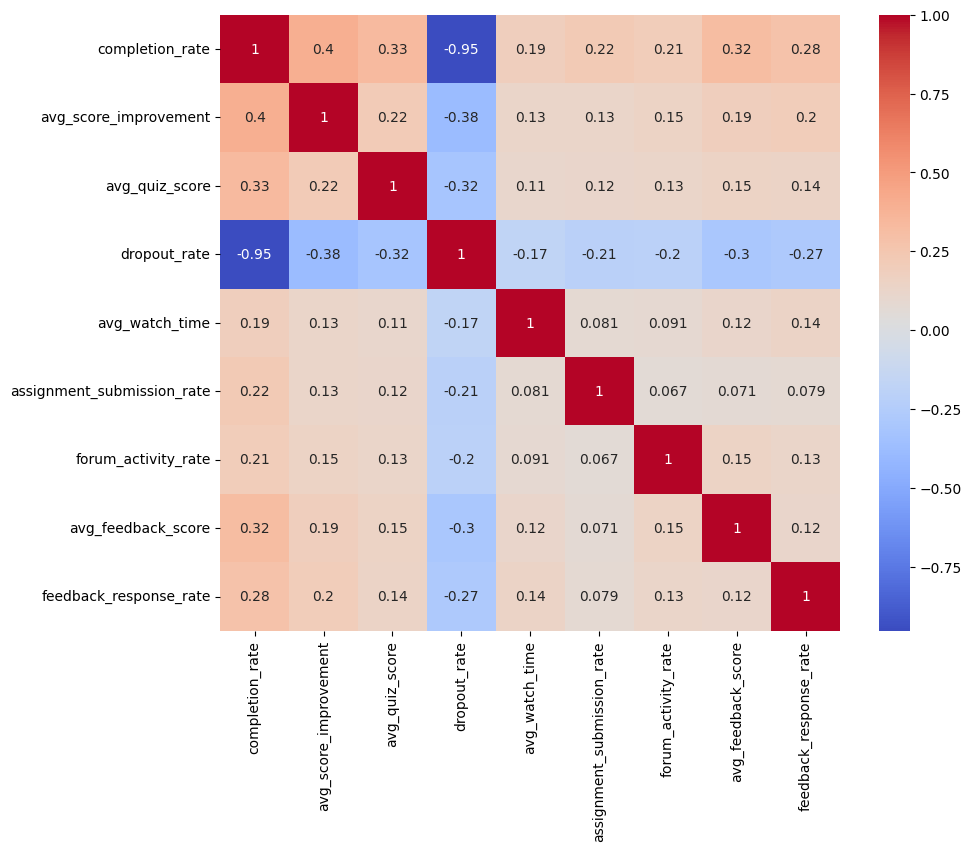

In [46]:
## Correlation analysis helps identify relationships between variables.
## we expect completion rate and dropout rate to show negative correlation.

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.show()

### Engagement vs Completion

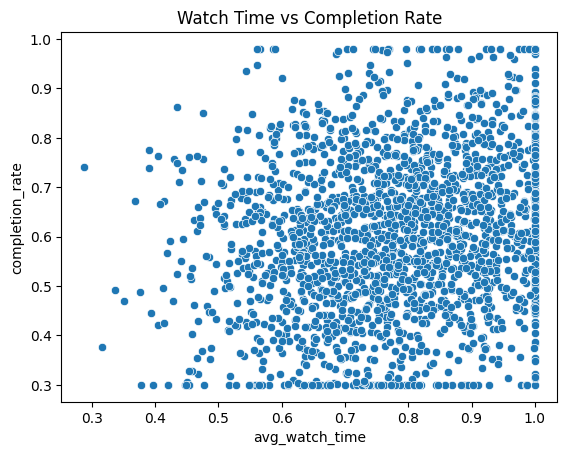

In [47]:
## Engagement vs Completion Rate
## This plot explores whether learners who spend more time watching videos tend to complete the course.

sns.scatterplot(
    x="avg_watch_time",
    y="completion_rate",
    data=df
)

plt.title("Watch Time vs Completion Rate")
plt.show()

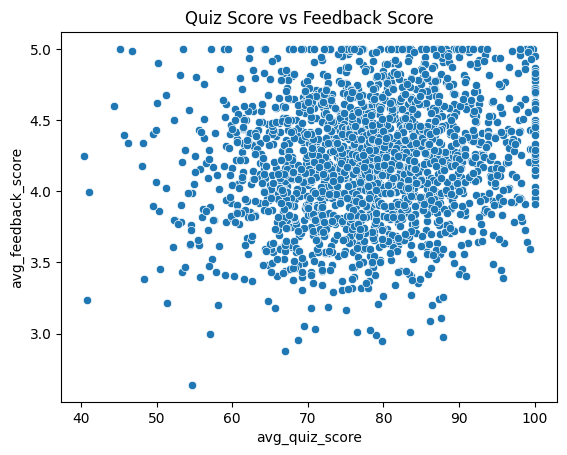

In [48]:
## Quiz Score vs Feedback

sns.scatterplot(
    x="avg_quiz_score",
    y="avg_feedback_score",
    data=df
)

plt.title("Quiz Score vs Feedback Score")
plt.show()

Observation:
Completion rate shows strong negative correlation with dropout rate.

Observation:
Higher watch time appears associated with higher completion rates.

## Define Instructor Effectiveness


### Instructor effectiveness should reflect three major aspects:

1. **Learning Outcomes**
   - Completion rate
   - Score improvement
   - Quiz scores

2. **Learner Engagement**
   - Watch time
   - Assignment submission rate
   - Forum activity

3. **Learner Satisfaction**
   - Feedback score

We combine these metrics into a single **Instructor Effectiveness Score** using a weighted formula.

### Normalize Feedback Score

In [49]:
## Normalize Feedback Score
## Feedback is on 1–5 scale, so convert to 0–1 scale.

df["feedback_score_norm"] = df["avg_feedback_score"] / 5

Feature scaling ensures that variables with larger ranges do not dominate the effectiveness score.

In [50]:
from sklearn.preprocessing import MinMaxScaler

## Normalize Important Features

scaler = MinMaxScaler()

features_to_scale = [
    "completion_rate",
    "avg_score_improvement",
    "avg_quiz_score",
    "avg_watch_time",
    "assignment_submission_rate",
    "forum_activity_rate"
]

df[features_to_scale] = scaler.fit_transform(df[features_to_scale])

In [51]:
## Define Instructor Effectiveness Score

df["effectiveness_score"] = (
    0.30 * df["completion_rate"] +
    0.20 * df["avg_score_improvement"] +
    0.10 * df["avg_quiz_score"] +
    0.15 * df["avg_watch_time"] +
    0.10 * df["assignment_submission_rate"] +
    0.05 * df["forum_activity_rate"] +
    0.10 * df["feedback_score_norm"]
)

### Convert Score to Tiers

To simplify interpretation, we convert effectiveness scores into three tiers:

- Low
- Medium
- High

In [52]:
## Convert Score into Effectiveness Tiers
## Quantiles ensure balanced classes.

df["effectiveness_tier"] = pd.qcut(
    df["effectiveness_score"],
    q=3,
    labels=["Low","Medium","High"]
)

In [53]:
## Check distribution

df["effectiveness_tier"].value_counts()

effectiveness_tier
Low       667
High      667
Medium    666
Name: count, dtype: int64

### Aggregate Batch Data to Instructor Level

Since instructors teach multiple batches, we aggregate batch-level metrics to instructor-level features.

We use the **mean** as the aggregation function because it represents the instructor's typical performance across batches.

In [54]:
## Aggregate Data to Instructor Level

instructor_df = df.groupby("instructor_id").agg({

    "completion_rate":"mean",
    "dropout_rate":"mean",
    "avg_score_improvement":"mean",
    "avg_quiz_score":"mean",

    "avg_watch_time":"mean",
    "assignment_submission_rate":"mean",
    "forum_activity_rate":"mean",

    "feedback_score_norm":"mean",
    "feedback_response_rate":"mean",

    "effectiveness_score":"mean"

}).reset_index()

In [55]:
instructor_df

,instructor_id,completion_rate,dropout_rate,avg_score_improvement,avg_quiz_score,avg_watch_time,assignment_submission_rate,forum_activity_rate,feedback_score_norm,feedback_response_rate,effectiveness_score
0,I_001,0.358658,0.470593,0.605253,0.646055,0.672327,0.635317,0.375209,0.843549,0.694858,0.560750
1,I_002,0.633639,0.247194,0.709411,0.693645,0.771799,0.698745,0.451731,0.868600,0.784338,0.696429
2,I_003,0.688892,0.234828,0.703843,0.691192,0.745203,0.705706,0.462047,0.890007,0.812132,0.711009
3,I_004,0.232836,0.547261,0.495047,0.625592,0.709681,0.677277,0.352917,0.815282,0.721460,0.504773
4,I_005,0.823158,0.145733,0.780993,0.762270,0.785317,0.835679,0.520220,0.840503,0.784197,0.790800
...,...,...,...,...,...,...,...,...,...,...,...
115,I_116,0.436920,0.412782,0.587176,0.641695,0.665276,0.546923,0.428773,0.818294,0.719787,0.570432
116,I_117,0.576052,0.312481,0.658131,0.680971,0.709879,0.751956,0.413625,0.861168,0.713759,0.661014
117,I_118,0.765813,0.202034,0.782416,0.783132,0.682022,0.772042,0.403079,0.928397,0.868611,0.757042
118,I_119,0.442054,0.399761,0.561456,0.676846,0.683998,0.688609,0.354117,0.863081,0.759761,0.588067


### Add Batch count feature

We also include the number of batches taught by each instructor. This helps capture how reliable the instructor performance estimates are.

In [56]:
## Add Batch Count Feature

batch_count = df.groupby("instructor_id")["batch_id"].count()

instructor_df["batch_count"] = batch_count.values

In [57]:
## Create Instructor Effectiveness Tier

instructor_df["effectiveness_tier"] = pd.qcut(
    instructor_df["effectiveness_score"],
    q=3,
    labels=["Low","Medium","High"]
)

## Machine Learning Model

We train a Random Forest classifier to predict instructor effectiveness tiers.

Random Forest is chosen because it performs well on tabular datasets and can capture nonlinear relationships between variables.

In [58]:
## prepare ML Dataset

X = instructor_df.drop(["instructor_id","effectiveness_tier"], axis=1)

y = instructor_df["effectiveness_tier"]

In [59]:
## Train-test split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [60]:
## Feature Scaling

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)



In [61]:
## Train Machine Learning Model

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## Model Evaluation

In [62]:
## Model Prediction

y_pred = model.predict(X_test)

In [63]:
## Accuracy

from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)

Model Accuracy: 0.9583333333333334


In [64]:
## classification report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

        High       1.00      1.00      1.00         6
         Low       1.00      0.86      0.92         7
      Medium       0.92      1.00      0.96        11

    accuracy                           0.96        24
   macro avg       0.97      0.95      0.96        24
weighted avg       0.96      0.96      0.96        24



Precision measures how many predicted instructors in a tier actually belong there.

Recall measures how many instructors of a tier were correctly identified.

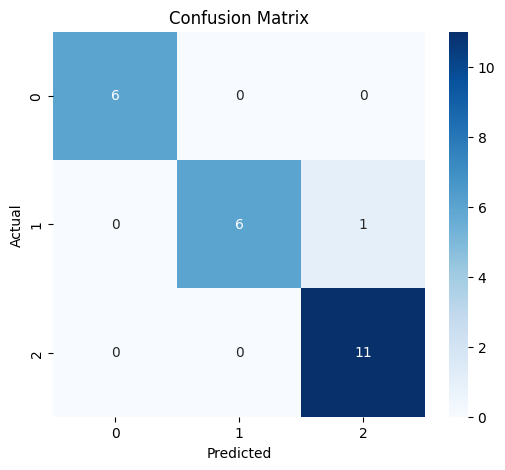

In [65]:
## Confusion Matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

### Feature Importance


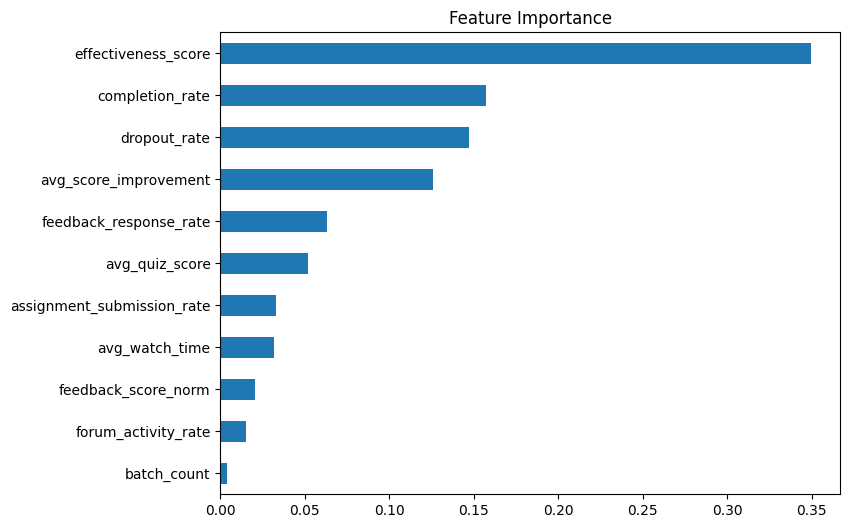

In [66]:
importance = pd.Series(
    model.feature_importances_,
    index=X.columns
)

importance.sort_values().plot(kind="barh", figsize=(8,6))

plt.title("Feature Importance")

plt.show()

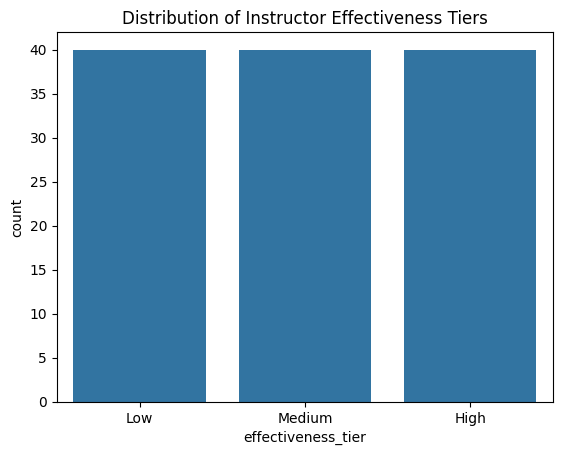

In [67]:
## Distribution of Instruction tiers

sns.countplot(
    x="effectiveness_tier",
    data=instructor_df
)

plt.title("Distribution of Instructor Effectiveness Tiers")

plt.show()

## Key Insights

The most influential features for predicting instructor effectiveness include:

- Completion rate
- Score improvement
- Watch time

This suggests that instructors who help learners complete courses and improve their scores tend to be more effective.

## Business Applications

This analysis can help EdTech platforms:

• Identify high-performing instructors  
• Provide targeted training for low-performing instructors  
• Improve course design and engagement strategies  
• Monitor course quality across batches

## Limitations

Several factors not included in this dataset may influence instructor effectiveness:

- Course difficulty
- Student demographics
- Class size
- Instructor experience

Therefore, this model should be used as a **decision-support tool** rather than a strict performance evaluation system.

## Mandatory Analysis Questions

### *Q1 Which features most influenced instructor effectiveness?*

Completion rate, score improvement, engagement.

### *Q2 Which variables could be misleading?*

course difficulty

student background

batch size

learner motivation

### *Q3 How could model fail in real world?*

Different course difficulty

Feedback bias

Small sample sizes

Student demographics

### *Q4 What additional data would help?*

student demographics

course difficulty

instructor experience

class size

time spent teaching

### *Q5 Should this model be used for evaluation?*

The model can provide useful insights but should not be the sole method of instructor evaluation. Human judgment and qualitative feedback should also be considered.

## Conclusion

This analysis explored instructor effectiveness using learner outcomes,
engagement metrics, and feedback data.

The results suggest that completion rate, score improvement, and learner
engagement are strong indicators of instructor effectiveness.

While the model provides useful insights, it should be used as a
decision-support tool rather than the sole method for evaluating
instructor performance.